# 安全帽模型验证 - 单张图像测试

最简单的demo，验证训练好的 best_stg1.pth 模型能否正确检测安全帽。

In [ ]:
import torch
import os
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import torchvision.transforms as T
import numpy as np

import sys
sys.path.append(r'D:\\AI\\Git\\DEIMv2')

from engine.core import YAMLConfig
from engine.deim import PostProcessor


# 配置 matplotlib 支持中文
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

使用设备: cpu


In [9]:
# ========== 配置路径 ==========
CONFIG_PATH = r'D:\\AI\\Git\\DEIMv2\\configs\\deimv2\\deimv2_hgnetv2_atto_helmet_cpu3.yml'
MODEL_PATH = r'D:\\AI\\Git\\DEIMv2\\outputs\\deimv2_hgnetv2_atto_helmet_gpu_3060\\best_stg1.pth'
TEST_IMAGE = r'D:\\AI\\Datasets\\sy-person\\中秋1-H3（90022）防疲劳-20260320092859.png'  # 修改为你的测试图片路径

# 检测阈值（训练模型置信度较低，用0.05）
CONF_THRESHOLD = 0.05

# 类别映射
CLASSES = {0: 'Helmet', 1: 'NoHelmet', 2: 'NoVest', 3: 'Vest'}
COLORS = {0: '#00FF00', 1: '#FF0000', 2: '#FFA500', 3: '#0000FF'}

print(f'配置: {CONFIG_PATH}')
print(f'模型: {MODEL_PATH}')
print(f'测试图: {TEST_IMAGE}')

配置: D:\\AI\\Git\\DEIMv2\\configs\\deimv2\\deimv2_hgnetv2_atto_helmet_cpu3.yml
模型: D:\\AI\\Git\\DEIMv2\\outputs\\deimv2_hgnetv2_atto_helmet_gpu_3060\\best_stg1.pth
测试图: D:\\AI\\Datasets\\sy-person\\中秋1-H3（90022）防疲劳-20260320092859.png


In [10]:
# ========== 加载模型 ==========
print('加载配置...')
cfg = YAMLConfig(CONFIG_PATH)
eval_size = cfg.yaml_cfg.get('eval_spatial_size', [640, 640])
print(f'评估尺寸: {eval_size}')

print('创建模型...')
model = cfg.model

print(f'加载权重: {MODEL_PATH}')
checkpoint = torch.load(MODEL_PATH, map_location='cpu', weights_only=False)

# 提取状态字典
if 'model' in checkpoint:
    state_dict = checkpoint['model']
elif 'ema' in checkpoint:
    state_dict = checkpoint['ema']['module']
else:
    state_dict = checkpoint

# 移除 'module.' 前缀
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v
    else:
        new_state_dict[k] = v

model.load_state_dict(new_state_dict, strict=False)
model = model.to(device)
model.eval()

postprocessor = cfg.postprocessor
postprocessor.eval_spatial_size = eval_size

print('✅ 模型加载成功！')

加载配置...
评估尺寸: [640, 640]
创建模型...
        ### Backbone.act: relu ###     
        ### Backbone.act: relu ###     
Loaded stage1 B0 HGNetV2 from local file.
     --- Use Gateway@False ---
     --- Use Share Bbox Head@True ---
     --- Use Share Score Head@False ---
     --- Wide Layer@1 ---
加载权重: D:\\AI\\Git\\DEIMv2\\outputs\\deimv2_hgnetv2_atto_helmet_gpu_3060\\best_stg1.pth
✅ 模型加载成功！


In [11]:
# ========== 预处理函数 ==========
def preprocess(image, target_size=(640, 640)):
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image)
    orig_w, orig_h = image.size
    image = image.resize(target_size)
    tensor = T.ToTensor()(image)
    tensor = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(tensor)
    return tensor, (orig_w, orig_h)

print('预处理函数定义完成')

预处理函数定义完成


In [12]:
# ========== 单张图像推理 ==========
if not os.path.exists(TEST_IMAGE):
    print(f'❌ 测试图像不存在: {TEST_IMAGE}')
    print('请修改 TEST_IMAGE 路径')
else:
    # 加载图像
    print(f'\n加载图像: {TEST_IMAGE}')
    orig_image = Image.open(TEST_IMAGE).convert('RGB')
    print(f'图像尺寸: {orig_image.size}')
    
    # 预处理
    image_tensor, (orig_w, orig_h) = preprocess(orig_image, target_size=tuple(eval_size))
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    # 推理
    print('运行推理...')
    with torch.no_grad():
        outputs = model(image_tensor)
    
    # 后处理
    orig_target_sizes = torch.tensor([[orig_h, orig_w]]).to(device)
    results = postprocessor(outputs, orig_target_sizes)[0]
    
    # 解析结果
    boxes = results['boxes'].cpu().numpy()
    scores = results['scores'].cpu().numpy()
    labels = results['labels'].cpu().numpy()
    
    detections = []
    for box, score, label in zip(boxes, scores, labels):
        if score >= CONF_THRESHOLD:
            class_id = int(label)
            detections.append({
                'bbox': box.tolist(),
                'class_id': class_id,
                'class_name': CLASSES.get(class_id, f'Class_{class_id}'),
                'confidence': float(score)
            })
    
    print(f'\n✅ 检测到 {len(detections)} 个目标:\n')
    for i, det in enumerate(detections[:10]):  # 最多显示10个
        print(f'  {i+1}. {det["class_name"]}: {det["confidence"]:.3f}')
    
    if len(detections) == 0:
        print('\n⚠️ 没有检测到任何目标！')
        print('可能原因：')
        print('  1. 阈值太高（当前0.05），尝试降低')
        print('  2. 模型权重未正确加载')
        print('  3. 测试图像不包含安全帽')


加载图像: D:\\AI\\Datasets\\sy-person\\中秋1-H3（90022）防疲劳-20260320092859.png
图像尺寸: (1920, 1080)
运行推理...

✅ 检测到 32 个目标:

  1. Vest: 0.226
  2. Vest: 0.220
  3. Helmet: 0.196
  4. Vest: 0.149
  5. Helmet: 0.146
  6. Vest: 0.126
  7. Helmet: 0.111
  8. Helmet: 0.109
  9. Vest: 0.103
  10. Vest: 0.100


C:\Users\lihs\AppData\Local\Temp\ipykernel_36764\4015290650.py:29: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from current font.
  plt.tight_layout()
C:\Users\lihs\AppData\Local\Temp\ipykernel_36764\4015290650.py:29: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  plt.tight_layout()
C:\Users\lihs\AppData\Local\Temp\ipykernel_36764\4015290650.py:29: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from current font.
  plt.tight_layout()
C:\Users\lihs\AppData\Local\Temp\ipykernel_36764\4015290650.py:29: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from current font.
  plt.tight_layout()
C:\Users\lihs\AppData\Local\Temp\ipykernel_36764\4015290650.py:29: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from current font.
  plt.tight_layout()
C:\Users\lihs\AppData\Local\Temp\ipykernel_36764\4015290650.py:29: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing fr

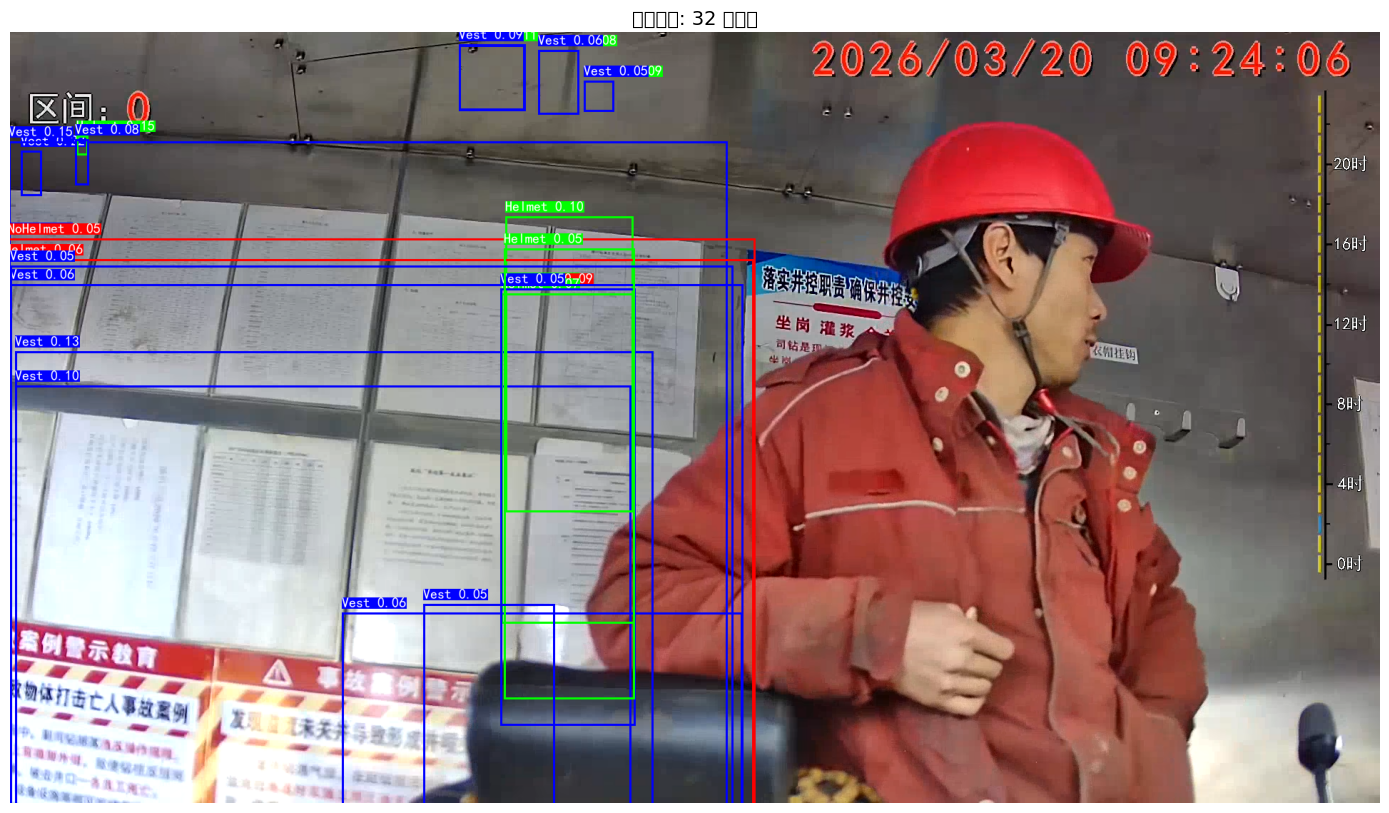


结果已保存: ./test_result.png


In [13]:
# ========== 可视化结果 ==========
if len(detections) > 0:
    result_image = orig_image.copy()
    draw = ImageDraw.Draw(result_image)
    
    try:
        font = ImageFont.truetype('C:/Windows/Fonts/simhei.ttf', 20)
    except:
        font = ImageFont.load_default()
    
    for det in detections:
        x1, y1, x2, y2 = [int(x) for x in det['bbox']]
        color = COLORS.get(det['class_id'], '#808080')
        
        # 绘制框
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        
        # 绘制标签
        label = f"{det['class_name']} {det['confidence']:.2f}"
        text_bbox = draw.textbbox((x1, y1-25), label, font=font)
        draw.rectangle(text_bbox, fill=color)
        draw.text((x1, y1-25), label, fill='white', font=font)
    
    # 显示
    plt.figure(figsize=(14, 10))
    plt.imshow(result_image)
    plt.axis('off')
    plt.title(f'检测结果: {len(detections)} 个目标', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # 保存
    output_path = './test_result.png'
    result_image.save(output_path)
    print(f'\n结果已保存: {output_path}')
else:
    # 显示原图
    plt.figure(figsize=(12, 8))
    plt.imshow(orig_image)
    plt.axis('off')
    plt.title('原图（无检测结果）')
    plt.show()

In [14]:
# ========== 统计信息 ==========
if len(detections) > 0:
    from collections import Counter
    class_counts = Counter([d['class_name'] for d in detections])
    
    print('\n检测统计:')
    print('=' * 30)
    for class_name, count in sorted(class_counts.items()):
        print(f'  {class_name}: {count}')
    print('=' * 30)
    print(f'  总计: {len(detections)}')
    
    # 平均置信度
    avg_conf = sum(d['confidence'] for d in detections) / len(detections)
    print(f'\n平均置信度: {avg_conf:.3f}')
    print(f'最高置信度: {max(d["confidence"] for d in detections):.3f}')
    print(f'最低置信度: {min(d["confidence"] for d in detections):.3f}')


检测统计:
  Helmet: 9
  NoHelmet: 4
  NoVest: 2
  Vest: 17
  总计: 32

平均置信度: 0.093
最高置信度: 0.226
最低置信度: 0.051
